In [1]:
import os

import equinox as eqx
import jax
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from pop_down_gym.pd_gym_stateless import PopDownGymStateless
from scripts.es.train.es_closed_loop import plot_test_set_trajectories
from scripts.es.train.es_open_loop import CubicTrajectory, rollout_open_loop

/home/cbd/.cache/pypoetry/virtualenvs/pop-down-gym--w4VtYJu-py3.9/lib/python3.9/site-packages/jaxtyping/__init__.py:221: UserWarning: jaxtyping version >=0.2.23 should be used with Equinox version >=0.11.1
  warnings.warn(


In [22]:
# Hyperparams
num_control_points = 10
num_eval_rollouts = 1000
simulation_steps = 100

# Set the seed for reproducibility
prng_key = jax.random.PRNGKey(0)

# Load the environment
env = PopDownGymStateless.create_env()

In [23]:

# Load the trajectory
prng_key, subkey = jax.random.split(prng_key)
initial_traj = CubicTrajectory(subkey, num_control_points, env.n_actions)
results_dir = (
    "../tmp/es/open_loop_sparse-noterminate_cubic/uncertainty_1.00/lr_1.0e-01"
)
best_trajectory = eqx.tree_deserialise_leaves(
    os.path.join(results_dir, "best_trajectory.eqx"), initial_traj
)

# Simulate a bunch of trajectories
keys = jax.random.split(prng_key, num_eval_rollouts)
rollout_test = lambda key, traj: rollout_open_loop(key, env, traj, simulation_steps)  # noqa
(
    rewards_test,
    states_test,
    t_test,
    reward_inputs_test,
    _,
    hit_goal_test,
    actions_test,
    params_test,
) = jax.vmap(rollout_test, in_axes=(0, None))(keys, best_trajectory)

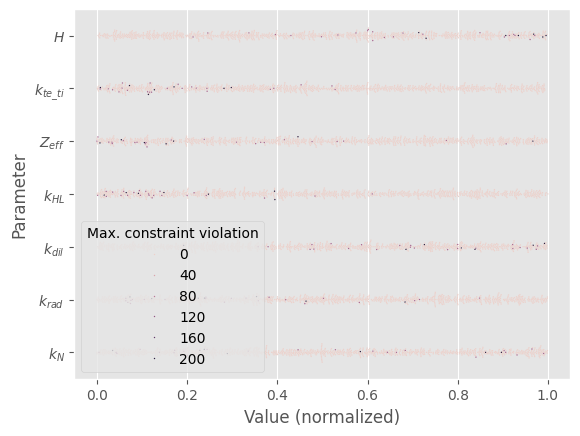

In [27]:
def max_constraint_violation(reward_inputs, upper_bounds):
    """Compute the maximum constraint violation."""
    max_reward_inputs = jax.tree_map(lambda x: x.max(axis=-1), reward_inputs)

    total_violation = 0.0
    for key in upper_bounds:
        violation = -jax.lax.cond(
            max_reward_inputs[key] >= upper_bounds[key] * 1.2,
            lambda _: env.reward_model.params["hit_barrier_reward"],
            lambda _: 0.0,
            None,
        )
        total_violation += violation

    return total_violation

violation = jax.vmap(max_constraint_violation, in_axes=(0, None))(
    reward_inputs_test, env.reward_model.limits
)

# Re-map param keys to latex
new_param_keys = {
    "ion_dilution": r"$k_{dil}$",
    "hl_factor": r"$k_{HL}$",
    "Hfactor": r"$H$",
    "Zeff": r"$Z_{eff}$",
    "Te_over_Ti": r"$k_{te\_ti}$",
    "tau_n_factor": r"$k_{N}$",
    "prad_mult": r"$k_{rad}$",
}
params = {new_param_keys[key]: value for key, value in params_test.items()}

# Normalize values by their min/max range
param_ranges = {
    new_param_keys[key]: (lb, ub - lb)
    for key, (lb, ub) in env.random_param_ranges.items()
}
normalized_params = {
    key: (value - param_ranges[key][0]) / param_ranges[key][1]
    for key, value in params.items()
}

# Create a dataframe for each parameter
df = pd.concat(
    [
        pd.DataFrame(
            {
                "Parameter": param,
                "Value (normalized)": value,
                "Max. constraint violation": violation,
            }
        )
        for param, value in normalized_params.items()
    ]
)

plt.style.use("ggplot")
ax = sns.swarmplot(
    x="Value (normalized)",
    y="Parameter",
    data=df,
    hue="Max. constraint violation",
    legend="brief",
    size=1,
)
# sns.move_legend(ax, "center left", bbox_to_anchor=(1, 1))

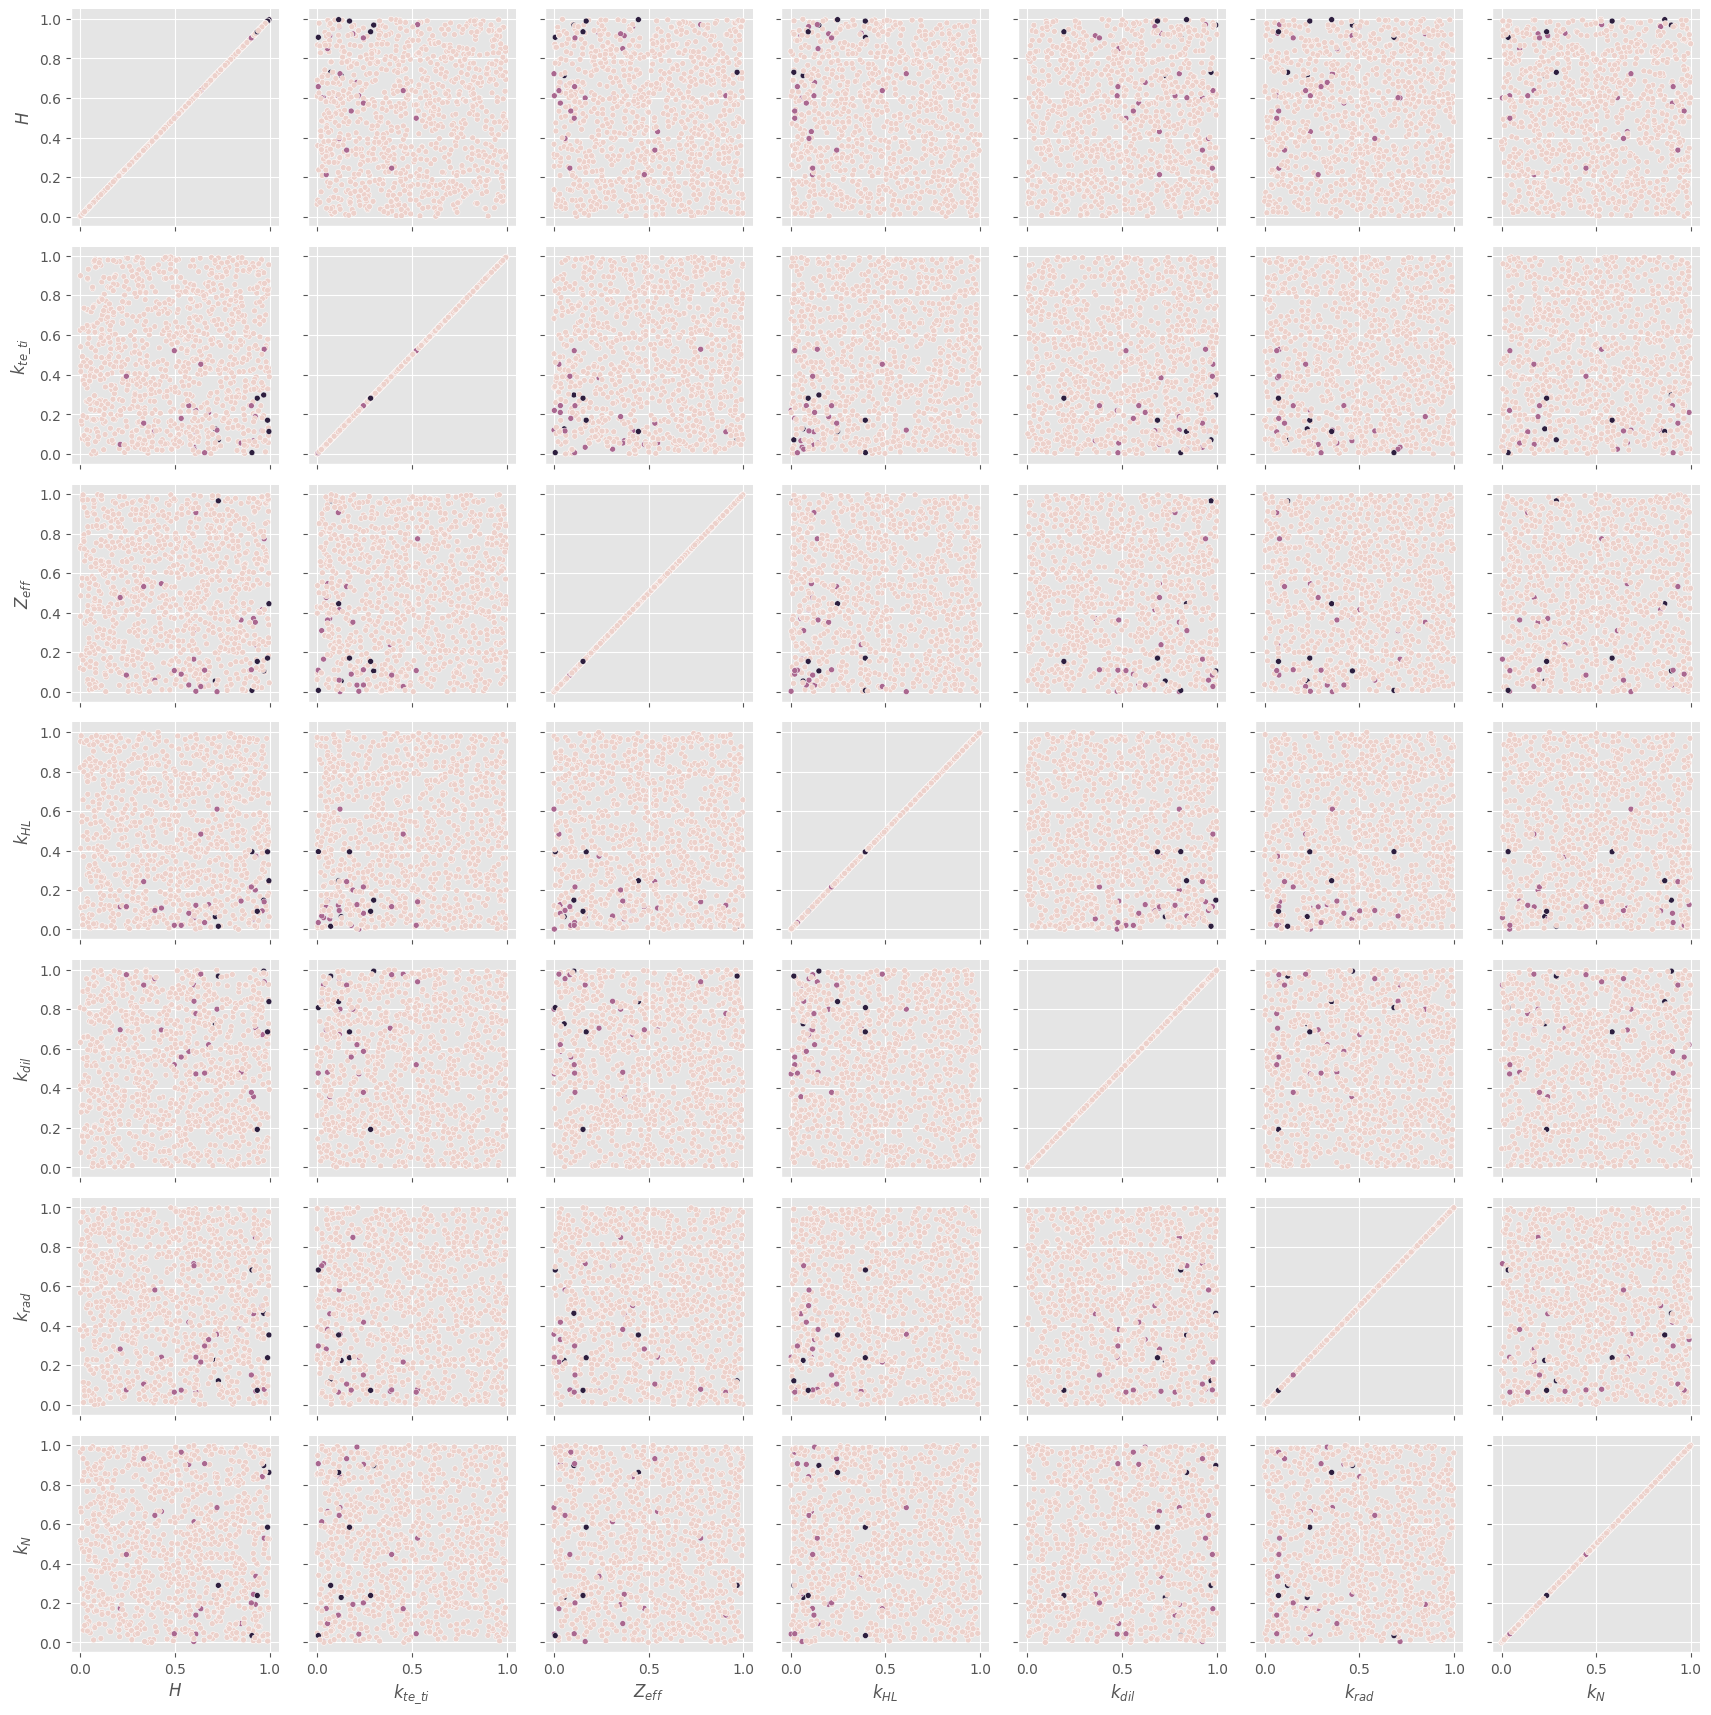

In [29]:
df = pd.DataFrame(
    {key: value for key, value in normalized_params.items()} | {
        "Max. constraint violation": violation,
    }
)
g = sns.PairGrid(
    df,
    hue="Max. constraint violation",
)
g.map(sns.scatterplot, size=2)
